# British Airways - Prediction Model

---

## Predictive modeling of customer bookings

This notebook follows a simple workflow: understand the data, engineer usable features, train a baseline model, improve it for class imbalance, and finish with visuals that explain the result.

In [108]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### Pandas checkpoint

These basic checks confirm the dataset loaded correctly and show the column types, missing values, and numeric summary we need before any modeling.

In [109]:
df = pd.read_csv("./customer_booking.csv", encoding="ISO-8859-1")
df_original = df.copy()
df_clean = df.copy()


In [110]:
df_original = df.copy()
df_clean = df.copy()

The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [111]:
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


### Column overview

This section maps each raw field to its meaning so the later feature engineering and model choices are easier to follow.

In [112]:
df_clean["flight_day"].unique()


<StringArray>
['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri']
Length: 7, dtype: str

In [113]:
df_clean.describe()


,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


The summary statistics help spot scale, skew, and outliers. That tells us which variables may need transformation or extra handling before the model is trained.

## TASK 1 - Exploratory Data Analysis and Feature Engineering

### Why this step comes first

We inspect the target balance and build a few compact features so the model has cleaner inputs and less noise to learn from.

In [114]:
df_clean.columns


Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='str')

In [115]:
row , columns = df_clean.shape


In [116]:
row

50000

In [117]:
columns

14

In [118]:
df_clean


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,Internet,RoundTrip,27,6,9,Sat,PERPNH,Australia,1,0,1,5.62,0
49996,1,Internet,RoundTrip,111,6,4,Sun,PERPNH,Australia,0,0,0,5.62,0
49997,1,Internet,RoundTrip,24,6,22,Sat,PERPNH,Australia,0,0,1,5.62,0
49998,1,Internet,RoundTrip,15,6,11,Mon,PERPNH,Australia,1,0,1,5.62,0


In [119]:
df_clean[df_clean.num_passengers > 4] 


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
37,6,Internet,RoundTrip,20,22,3,Fri,AKLICN,South Korea,1,1,1,6.62,0
118,6,Internet,RoundTrip,172,28,0,Sat,AKLKUL,New Zealand,0,0,1,8.83,0
155,5,Internet,RoundTrip,239,17,12,Thu,AKLKUL,Malaysia,1,0,1,8.83,0
170,5,Mobile,RoundTrip,238,21,8,Fri,AKLKUL,New Zealand,1,1,1,8.83,0
177,5,Internet,RoundTrip,206,17,13,Sun,AKLKUL,Malaysia,1,0,0,8.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49898,6,Internet,RoundTrip,96,6,12,Tue,PENTPE,Malaysia,1,0,0,4.67,1
49941,5,Internet,RoundTrip,85,6,6,Sat,PENTPE,Malaysia,1,0,0,4.67,1
49951,8,Internet,RoundTrip,133,6,8,Wed,PENTPE,Malaysia,0,0,0,4.67,0
49953,8,Internet,RoundTrip,328,6,17,Sat,PENTPE,Malaysia,1,1,1,4.67,1


In [120]:
df_booking_completed = df_clean["booking_complete"].value_counts().sort_index()
df_booking_completed


booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [121]:
df_clean[["num_passengers", "trip_type","length_of_stay", "purchase_lead"]]


,num_passengers,trip_type,length_of_stay,purchase_lead
0,2,RoundTrip,19,262
1,1,RoundTrip,20,112
2,2,RoundTrip,22,243
3,1,RoundTrip,31,96
4,2,RoundTrip,22,68
...,...,...,...,...
49995,2,RoundTrip,6,27
49996,1,RoundTrip,6,111
49997,1,RoundTrip,6,24
49998,1,RoundTrip,6,15


In [122]:
df_clean["trip_type"].unique()


<StringArray>
['RoundTrip', 'CircleTrip', 'OneWay']
Length: 3, dtype: str

In [123]:
len(df_clean["purchase_lead"])


50000

In [124]:
df_clean["stay_lead_ratio"] = df_clean["purchase_lead"].div(df_clean["length_of_stay"].replace(0, pd.NA))
df_clean["stay_lead_ratio"] = df_clean["stay_lead_ratio"].fillna(0)


### Why this feature engineering matters

This ratio and the categorical encoding turn raw booking data into model-ready inputs. The goal is to preserve useful signal while making the variables numeric and easier for the forest to split on.

In [125]:
df_clean["trip_type"].unique()


<StringArray>
['RoundTrip', 'CircleTrip', 'OneWay']
Length: 3, dtype: str

In [126]:
channel_booking = df_clean.groupby(["sales_channel"])["booking_complete"].agg(['sum' , 'count' , 'mean'])
channel_booking


,sum,count,mean
sales_channel,,,
Internet,6869,44382,0.154770
Mobile,609,5618,0.108402


In [127]:
trip_booking = df_clean.groupby(['trip_type'])['booking_complete'].agg(['sum'  , 'mean'])
trip_booking


,sum,mean
trip_type,,
CircleTrip,5,0.043103
OneWay,20,0.051680
RoundTrip,7453,0.150575


In [128]:
day_booking = df_clean.groupby(['flight_day'])['booking_complete'].sum().sort_index(ascending=False)
day_booking


flight_day
Wed    1252
Tue    1129
Thu    1122
Sun     927
Sat     861
Mon    1204
Fri     983
Name: booking_complete, dtype: int64

In [129]:
z = stats.zscore(df_clean['length_of_stay'])
outliers_z = df_clean[abs(z) > 3]
print("Z-score outliers count : ", len(outliers_z))


Z-score outliers count :  824


In [130]:
z = stats.zscore(df_clean['purchase_lead'])
outliers_z = df_clean[abs(z) > 3]
print("Z-score outliers count : ", len(outliers_z))


Z-score outliers count :  967


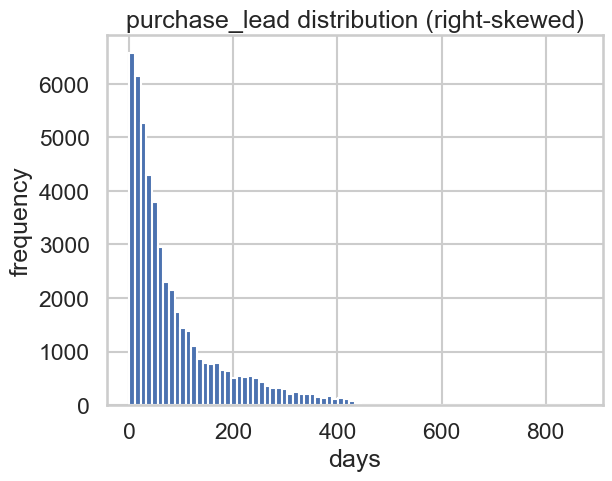

In [131]:
df_clean['purchase_lead'].hist(bins=80)
plt.title("purchase_lead distribution (right-skewed)")
plt.xlabel('days')
plt.ylabel('frequency')
plt.show()


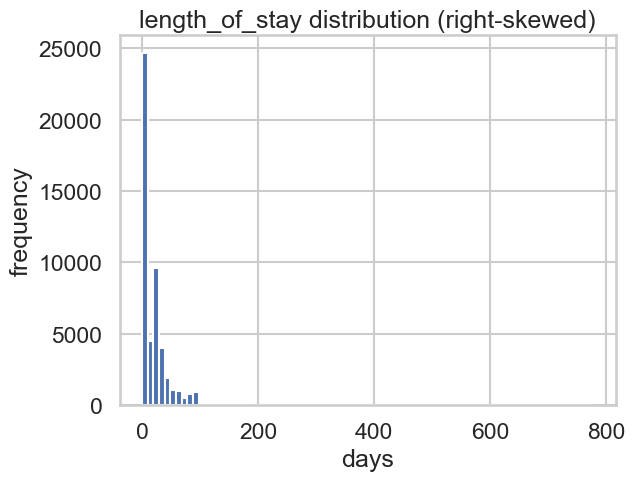

In [132]:
df_clean['length_of_stay'].hist(bins=80)
plt.title("length_of_stay distribution (right-skewed)")
plt.xlabel('days')
plt.ylabel('frequency')
plt.show()


In [133]:
q1 = df_clean.length_of_stay.quantile(0.25)
q3 = df_clean.length_of_stay.quantile(0.75)


In [134]:
IQR = q3 - q1 
IQR

np.float64(23.0)

In [135]:
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR

lower_limit,upper_limit

(np.float64(-29.5), np.float64(62.5))

In [136]:
outliers = df_clean[(df_clean['length_of_stay'] < lower_limit)  |(df_clean['length_of_stay'] > upper_limit)]
len(outliers)


3807

In [137]:
q1 = df_clean.purchase_lead.quantile(0.25)
q3 = df_clean.purchase_lead.quantile(0.75)
q1,q3


(np.float64(21.0), np.float64(115.0))

In [138]:
IQR = q3-q1
IQR

np.float64(94.0)

In [139]:
upper_limit = q3 + 1.5*IQR
lower_limit = q1 - 1.5*IQR

upper_limit,lower_limit

(np.float64(256.0), np.float64(-120.0))

In [140]:
outliers = df_clean[(df_clean['purchase_lead'] < lower_limit) | (df_clean['purchase_lead'] > upper_limit)]
len(outliers)


3456

In [141]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output= False).set_output(transform='pandas')

In [142]:
ohe_transform = ohe.fit_transform(df_clean[['sales_channel']])


In [143]:
ohe_transform

,sales_channel_Internet,sales_channel_Mobile
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
49995,1.0,0.0
49996,1.0,0.0
49997,1.0,0.0
49998,1.0,0.0


In [144]:
df_clean = pd.concat([df_clean, ohe_transform], axis=1).drop(columns=['sales_channel'])


In [145]:
ohe_transform_trip = ohe.fit_transform(df_clean[['trip_type']])


In [146]:
ohe_transform_trip

,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
49995,0.0,0.0,1.0
49996,0.0,0.0,1.0
49997,0.0,0.0,1.0
49998,0.0,0.0,1.0


In [147]:
df_clean = pd.concat([df_clean, ohe_transform_trip], axis=1).drop(columns='trip_type')


In [148]:
df_clean = df_clean.drop(columns=['route', 'booking_origin'])

In [149]:
df_clean["flight_day"] = df_original["flight_day"]


In [150]:
# normalize text and map
day_map = {"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7}
day_num = df_clean["flight_day"].astype(str).str.strip().str.title().map(day_map)

# cyclical encoding
df_clean["flight_day_sin"] = np.sin(2 * np.pi * day_num / 7)
df_clean["flight_day_cos"] = np.cos(2 * np.pi * day_num / 7)

# drop original day column
df_clean = df_clean.drop(columns=["flight_day"])

# quick check
print("NaNs in day_num:", day_num.isna().sum())
df_clean[["flight_day_sin", "flight_day_cos"]]


NaNs in day_num: 0


,flight_day_sin,flight_day_cos
0,-7.818315e-01,0.623490
1,-7.818315e-01,0.623490
2,4.338837e-01,-0.900969
3,-7.818315e-01,0.623490
4,4.338837e-01,-0.900969
...,...,...
49995,-7.818315e-01,0.623490
49996,-2.449294e-16,1.000000
49997,-7.818315e-01,0.623490
49998,7.818315e-01,0.623490


In [151]:

df_clean["flight_day_sin"] = df_clean["flight_day_sin"].round(6)
df_clean["flight_day_cos"] = df_clean["flight_day_cos"].round(6)

In [152]:
df_clean

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,stay_lead_ratio,sales_channel_Internet,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip,flight_day_sin,flight_day_cos
0,2,262,19,7,1,0,0,5.52,0,13.789474,1.0,0.0,0.0,0.0,1.0,-0.781831,0.623490
1,1,112,20,3,0,0,0,5.52,0,5.6,1.0,0.0,0.0,0.0,1.0,-0.781831,0.623490
2,2,243,22,17,1,1,0,5.52,0,11.045455,1.0,0.0,0.0,0.0,1.0,0.433884,-0.900969
3,1,96,31,4,0,0,1,5.52,0,3.096774,1.0,0.0,0.0,0.0,1.0,-0.781831,0.623490
4,2,68,22,15,1,0,1,5.52,0,3.090909,1.0,0.0,0.0,0.0,1.0,0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,27,6,9,1,0,1,5.62,0,4.5,1.0,0.0,0.0,0.0,1.0,-0.781831,0.623490
49996,1,111,6,4,0,0,0,5.62,0,18.5,1.0,0.0,0.0,0.0,1.0,-0.000000,1.000000
49997,1,24,6,22,0,0,1,5.62,0,4.0,1.0,0.0,0.0,0.0,1.0,-0.781831,0.623490
49998,1,15,6,11,1,0,1,5.62,0,2.5,1.0,0.0,0.0,0.0,1.0,0.781831,0.623490


## TASK 2 - Machine learning model using Random Forest and evaluation metrics

In [153]:
# Task 2: Random Forest classifier - training and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# define features X and target y
y = df_clean['booking_complete']
# drop the target and any non-feature columns (keep numeric and already-encoded columns)
X = df_clean.drop(columns=['booking_complete', 'route', 'booking_origin'], errors='ignore')

# train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# instantiate and train the Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# predictions and evaluation

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Why the baseline model is here

This gives a reference score before any balancing or threshold changes, so we can measure whether the later adjustments actually help.

In [154]:
# predictions and evaluation

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_test_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

Train accuracy: 0.9996
Test accuracy: 0.8487

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     10631
           1       0.45      0.05      0.09      1869

    accuracy                           0.85     12500
   macro avg       0.65      0.52      0.51     12500
weighted avg       0.79      0.85      0.79     12500

Confusion matrix:
[[10512   119]
 [ 1772    97]]


In [155]:
# quick improvement attempt: add class balancing and reduce tree overfitting
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
    max_depth=12,
    min_samples_leaf=2
)
rf_balanced.fit(X_train, y_train)

y_train_pred_balanced = rf_balanced.predict(X_train)
y_test_pred_balanced = rf_balanced.predict(X_test)

train_accuracy_balanced = accuracy_score(y_train, y_train_pred_balanced)
test_accuracy_balanced = accuracy_score(y_test, y_test_pred_balanced)

print("Balanced random forest")
print(f"Train accuracy: {train_accuracy_balanced:.4f}")
print(f"Test accuracy: {test_accuracy_balanced:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_test_pred_balanced))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_balanced))

Balanced random forest
Train accuracy: 0.7877
Test accuracy: 0.7280

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83     10631
           1       0.27      0.46      0.34      1869

    accuracy                           0.73     12500
   macro avg       0.58      0.62      0.58     12500
weighted avg       0.80      0.73      0.76     12500

Confusion matrix:
[[8233 2398]
 [1002  867]]


### Why we rebalance the model

The target is imbalanced, so class weights and a little regularization help the forest pay more attention to bookings that complete.

### Why threshold tuning helps

The balanced forest is better at finding the positive class, but the default `0.5` cutoff still makes it too conservative. The next step is to use a validation split to choose a lower decision threshold that improves class 1 recall without using the final test set for model selection.

### Why threshold tuning comes next

The default cutoff can be too strict, so we tune the decision threshold on validation data to improve recall without touching the test set.

In [156]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, f1_score

# split the training data again so the threshold is tuned on validation only
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
    max_depth=12,
    min_samples_leaf=2
)
rf_tuned.fit(X_train_inner, y_train_inner)

val_proba = rf_tuned.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_threshold = thresholds[f1_scores.argmax()]

test_proba = rf_tuned.predict_proba(X_test)[:, 1]
y_test_pred_tuned = (test_proba >= best_threshold).astype(int)
y_train_pred_tuned = rf_tuned.predict(X_train_inner)

train_accuracy_tuned = accuracy_score(y_train_inner, y_train_pred_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)

print("Threshold-tuned balanced random forest")
print(f"Best threshold: {best_threshold:.3f}")
print(f"Train accuracy: {train_accuracy_tuned:.4f}")
print(f"Test accuracy: {test_accuracy_tuned:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_test_pred_tuned))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred_tuned))

Threshold-tuned balanced random forest
Best threshold: 0.470
Train accuracy: 0.8027
Test accuracy: 0.7078

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81     10631
           1       0.26      0.51      0.34      1869

    accuracy                           0.71     12500
   macro avg       0.58      0.63      0.58     12500
weighted avg       0.80      0.71      0.74     12500

Confusion matrix:
[[7899 2732]
 [ 921  948]]


### Final Task 2 takeaway

The original random forest had the highest overall accuracy, but it missed most positive bookings. The balanced and threshold-tuned versions reduced that problem by increasing class 1 recall, so they are better if the goal is to catch more completed bookings. For a production decision, the tuned model is the better tradeoff because it is more useful on the minority class, even though total accuracy is lower.

### Useful visual checks

Two visuals help interpret the model quickly: a confusion matrix to show which class is being missed, and a feature-importance chart to show which inputs the forest relies on most.

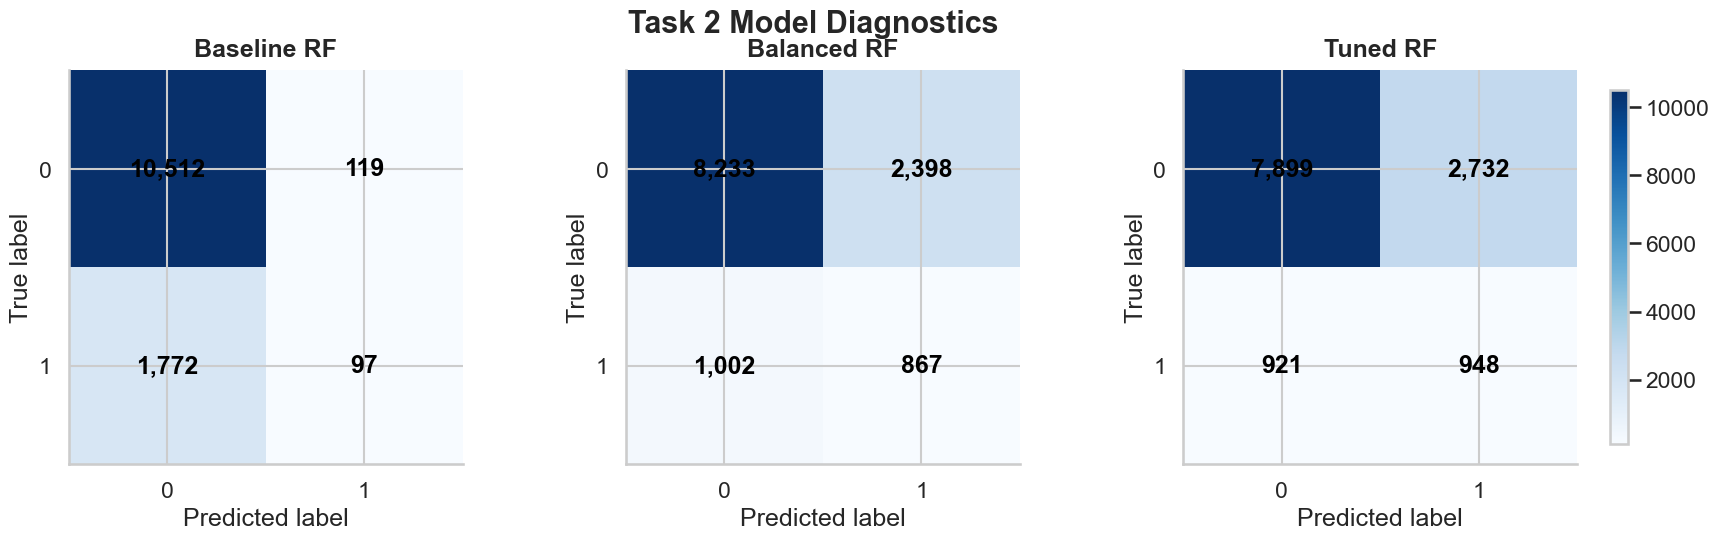

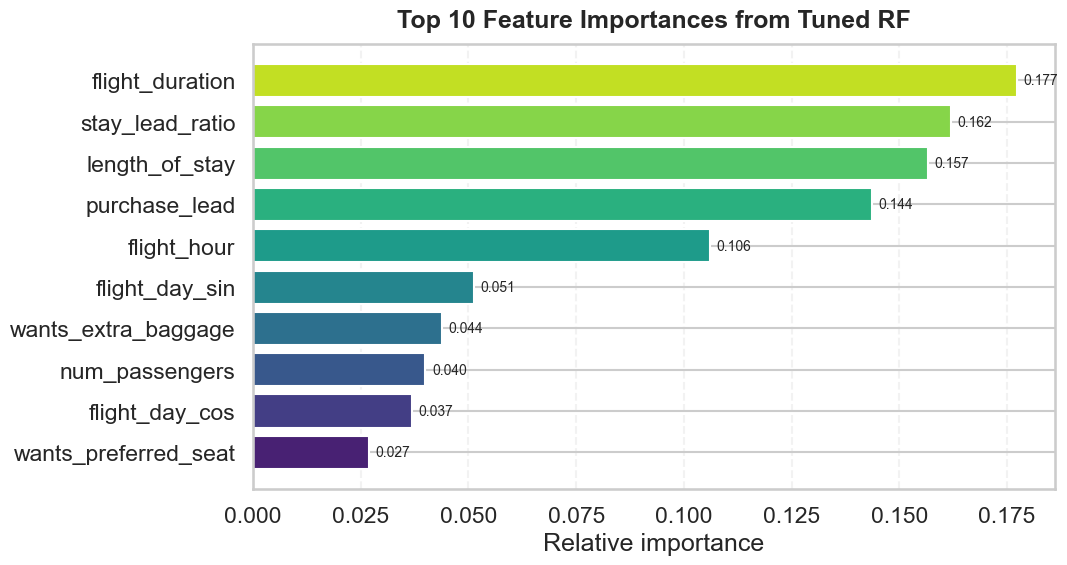

In [157]:
import pandas as pd
import seaborn as sns

def plot_confusion_matrix(ax, matrix, title):
    image = ax.imshow(matrix, cmap='Blues', interpolation='nearest')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'])
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            ax.text(column_index, row_index, f'{value:,}', ha='center', va='center', color='black', fontweight='semibold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return image

sns.set_theme(style='whitegrid', context='talk')

baseline_cm = confusion_matrix(y_test, y_test_pred)
balanced_cm = confusion_matrix(y_test, y_test_pred_balanced)
tuned_cm = confusion_matrix(y_test, y_test_pred_tuned)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
image = plot_confusion_matrix(axes[0], baseline_cm, 'Baseline RF')
plot_confusion_matrix(axes[1], balanced_cm, 'Balanced RF')
plot_confusion_matrix(axes[2], tuned_cm, 'Tuned RF')
fig.colorbar(image, ax=axes, fraction=0.03, pad=0.02, shrink=0.9)
fig.suptitle('Task 2 Model Diagnostics', fontsize=22, fontweight='bold', y=1.05)
plt.show()

feature_importances = pd.Series(rf_tuned.feature_importances_, index=X_train_inner.columns).sort_values(ascending=False)
top_features = feature_importances.head(10).sort_values()

plt.figure(figsize=(11, 6))
palette = sns.color_palette('viridis', len(top_features))
bars = plt.barh(top_features.index, top_features.values, color=palette)
plt.title('Top 10 Feature Importances from Tuned RF', fontweight='bold', pad=12)
plt.xlabel('Relative importance')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.25)
for bar in bars:
    value = bar.get_width()
    plt.text(value + 0.0015, bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### Why the diagnostics matter

These plots make the tradeoff visible: the confusion matrices show the errors, and the feature chart shows what the final model depends on most.